# Reproducibility in Data Science: A Data Ethics Project

## Background and Context

### The Reproducibility Crisis in Data Science
Reproducibility is a fundamental principle of the scientific method, requiring that research findings can be independently verified using the same data and methodology. However, many modern data science and machine learning studies are difficult or impossible to reproduce. This challenge, often referred to as the "reproducibility crisis," raises serious concerns about the reliability and transparency of scientific research.

In machine learning, reproducibility is particularly complex due to factors such as incomplete documentation, missing hyperparameters, differences in computational environments, and unstated data preprocessing steps. Even when datasets are publicly available, small variations in implementation can lead to significantly different results.

### Machine Learning and Wine Quality Prediction
The selected paper, *“Wine Feature Importance and Quality Prediction: A Comparative Study of Machine Learning Algorithms with Unbalanced Data” (2023)*, applies machine learning techniques to predict wine quality based on physicochemical properties.

Traditionally, wine quality has been assessed by human experts, making it a subjective and time-consuming process. Machine learning offers a more automated and scalable approach by identifying patterns in chemical composition that correlate with perceived quality. However, the reliability of these models depends heavily on reproducibility and transparency in their implementation.

The study evaluates multiple machine learning models, including Support Vector Machine (SVM), Random Forest (RF), Gradient Boosting (GB), K-Nearest Neighbors (KNN), and Decision Tree (DT), reporting that SVM achieved the highest accuracy of approximately 96%.

---

## Project Overview

This project attempts to reproduce the results of the selected paper using the same publicly available dataset and described methodology. The goal is not only to replicate the reported findings but also to identify and analyze challenges encountered during the reproduction process.

The project focuses on two key areas:

1. **Technical Reproducibility**
   - Recreating data preprocessing steps (label transformation, feature selection, standardization)
   - Implementing the machine learning models described in the paper
   - Reproducing evaluation metrics such as accuracy, precision, recall, and F1-score
   - Comparing reproduced results with the original study

2. **Ethical Implications of Reproducibility**
   - Impact of missing or unclear methodological details
   - Barriers to independent verification of results
   - Risks of relying on non-reproducible models in real-world applications
   - Implications for scientific integrity and public trust

---

## Data Sources

### Primary Dataset (Used in the Study)
The project utilizes the **UCI Wine Quality Dataset**, which is publicly available and widely used for machine learning research.

- Contains 1,599 observations of red wine samples  
- Includes 11 physicochemical features (e.g., acidity, alcohol, sulphates)  
- Target variable: wine quality score (0–10 scale)  

For this project, the quality scores are transformed into categorical labels:
- Low quality (score < 5)  
- Medium quality (score 5–6)  
- High quality (score ≥ 7)  

---

### Original Data Source

1. **UCI Machine Learning Repository – Wine Quality Dataset**
   - URL: https://archive.ics.uci.edu/ml/datasets/wine+quality  
   - Contains: Red and white wine physicochemical data  
   - Format: CSV files  

---

## Key Challenges in Reproducibility

During the reproduction process, several common challenges are expected, including:

- Missing hyperparameter specifications  
- Unclear data preprocessing steps  
- Lack of explicit train/test split details  
- Differences in random seed initialization  
- Variations in handling class imbalance (e.g., SMOTE)  
- Software and library version differences  

These challenges highlight the importance of transparency and documentation in data science research.

---

## Project Goal

The ultimate goal of this project is to critically evaluate the reproducibility of a published machine learning study, document all steps and challenges encountered, and provide recommendations for improving reproducibility in future research.

## Section 1. Import Libraries

In [32]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing and model selection
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Machine learning models
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Feature importance / permutation importance
from sklearn.inspection import permutation_importance


## Section 2. Import Data



In [5]:
# Load dataset
df_wine = pd.read_csv("Data/winequality-red.csv", sep=';')

# Preview data
df_wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## Section 3. Exploratory Data Analysis



In [7]:
# Shape of dataset
df_wine.shape

(1599, 12)

In [8]:
# Column info
df_wine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [9]:
# Summary statistics
df_wine.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


**Summary of Data** 
* Dataset size: 1599 rows, 12 columns
* No missing values
* All features are numeric
* Quality ranges from 3 to 8

In [14]:
# Distribution of target variable, check class imbalance
df_wine['quality'].value_counts().sort_index()

quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64

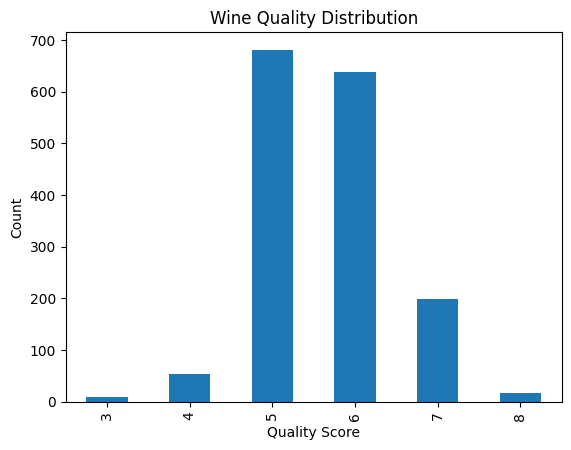

In [15]:
#plot class distributioon
df_wine['quality'].value_counts().sort_index().plot(kind = 'bar')
plt.title("Wine Quality Distribution")
plt.xlabel("Quality Score")
plt.ylabel("Count")
plt.show()

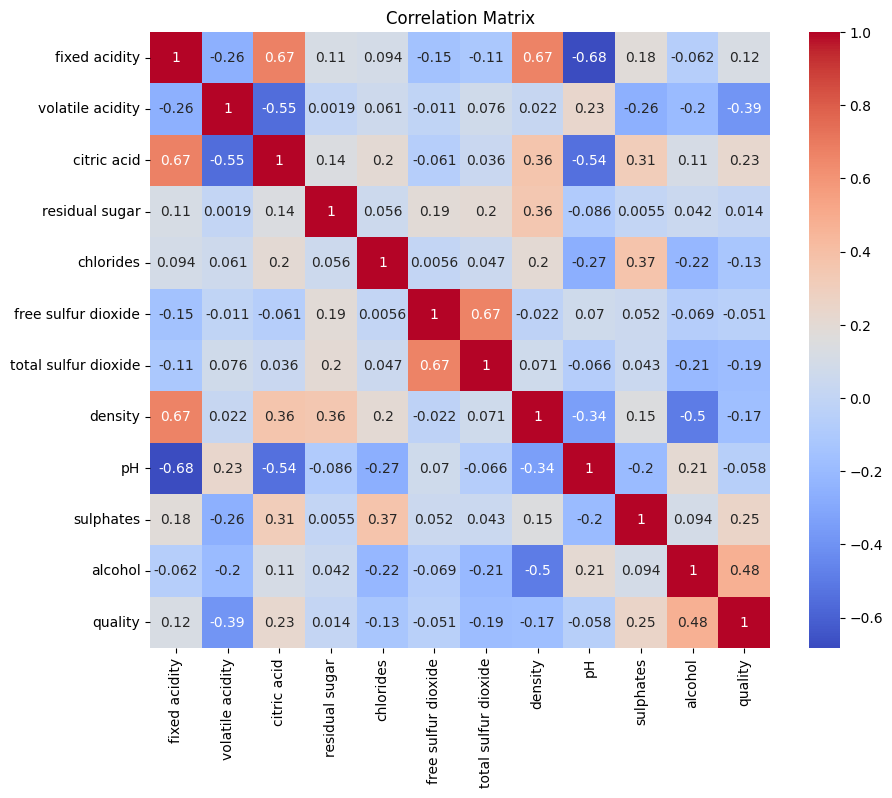

In [16]:
#Correlation matrix
plt.figure(figsize = (10,8))
sns.heatmap(df_wine.corr(), annot = True, cmap = 'coolwarm')
plt.title("Correlation Matrix")
plt.show()

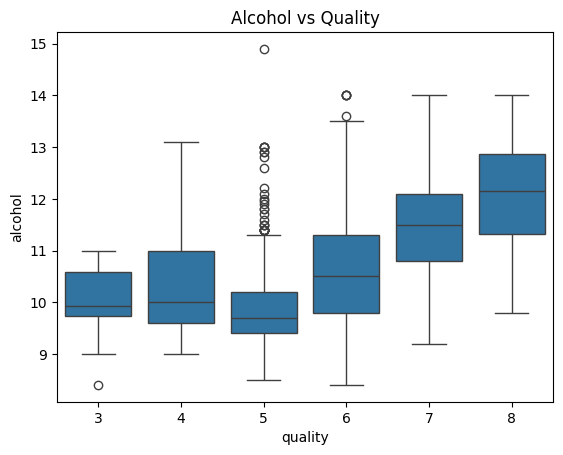

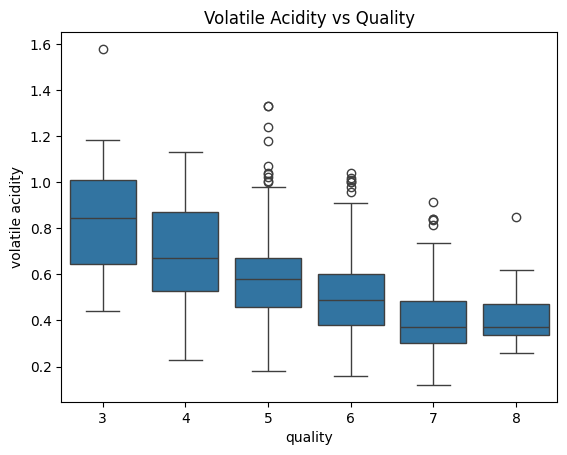

In [17]:
#Key feature relationships
# Alcohol vs Quality
sns.boxplot(x = 'quality', y = 'alcohol', data = df_wine)
plt.title("Alcohol vs Quality")
plt.show()

# Volatile Acidity vs Quality
sns.boxplot(x = 'quality', y = 'volatile acidity', data = df_wine)
plt.title("Volatile Acidity vs Quality")
plt.show()

In [18]:
# Correlation with target variable
df_wine.corr()['quality'].sort_values(ascending = False)

quality                 1.000000
alcohol                 0.476166
sulphates               0.251397
citric acid             0.226373
fixed acidity           0.124052
residual sugar          0.013732
free sulfur dioxide    -0.050656
pH                     -0.057731
chlorides              -0.128907
density                -0.174919
total sulfur dioxide   -0.185100
volatile acidity       -0.390558
Name: quality, dtype: float64

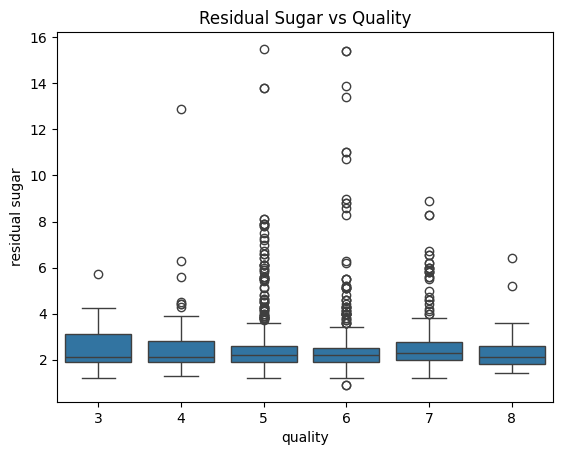

In [19]:
#drop residual sugar insight
sns.boxplot(x = 'quality', y = 'residual sugar', data = df_wine)
plt.title("Residual Sugar vs Quality")
plt.show()

### Exploratory Data Analysis Results

The exploratory data analysis was conducted to better understand the structure, distribution, and relationships within the dataset prior to model development.

#### Dataset Structure
The dataset contains 1,599 observations and 12 variables, all of which are numerical. There are no missing values, indicating that the dataset is complete and does not require imputation. This confirms that the data is clean and suitable for machine learning analysis without additional data cleaning steps.

#### Distribution of Target Variable
The distribution of the target variable (wine quality) reveals a clear class imbalance. The majority of observations fall within quality scores of 5 and 6, while significantly fewer samples exist at the lower and higher ends of the scale (3-8). 

This imbalance is important because it can bias machine learning models toward predicting the majority classes more frequently. This finding aligns with the original study, which identifies the dataset as unbalanced and applies sampling techniques to address this issue.

#### Correlation Analysis
The correlation matrix provides insight into the relationships between input features and the target variable. The strongest positive correlation with wine quality is observed for alcohol, while the strongest negative correlation is observed for volatile acidity.

Specifically:
- Alcohol shows a moderate positive correlation with quality (~0.48), indicating that higher alcohol content is generally associated with higher-quality wine.
- Volatile acidity shows a moderate negative correlation (~-0.39), suggesting that higher acidity levels negatively impact wine quality.
- Sulphates and citric acid also show smaller positive relationships with quality.

These findings are consistent with the results presented in the original paper and help validate the dataset.

#### Feature Relationship Insights
The boxplot analysis further reinforces these relationships:
- Alcohol increases as wine quality increases, showing a clear upward trend across quality categories.
- Volatile acidity decreases as wine quality increases, indicating an inverse relationship.

These visual patterns support the correlation analysis and confirm that these variables are important predictors of wine quality.

#### Residual Sugar Analysis
Residual sugar demonstrates little to no clear relationship with wine quality. The distribution of residual sugar values remains relatively consistent across all quality levels, and its correlation with the target variable is near zero.

This suggests that residual sugar does not significantly contribute to predicting wine quality. This observation supports the methodology used in the original study, where residual sugar was excluded during feature selection to improve model performance.

#### Summary
Overall, the exploratory data analysis confirms the key characteristics described in the original paper. The dataset is clean but imbalanced, and several features particularly alcohol and volatile acidity play a significant role in determining wine quality. These findings provide a strong foundation for the preprocessing and modeling steps that follow.

## Section 4. Data Preprocessing



In [20]:
# Create a copy of the original dataset for preprocessing
df_wine_preprocessed = df_wine.copy()

# Preview
df_wine_preprocessed.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [21]:
# Check for duplicate rows
df_wine_preprocessed.duplicated().sum()

np.int64(240)

In [22]:
# Remove duplicate rows
df_wine_preprocessed = df_wine_preprocessed.drop_duplicates()

# Check updated shape
df_wine_preprocessed.shape

(1359, 12)

In [23]:
# Create categorical wine quality label
# 0 = bad (<5), 1 = normal (5-6), 2 = good (7+)

def categorize_quality(quality_score):
    if quality_score < 5:
        return 0
    elif quality_score < = 6:
        return 1
    else:
        return 2

df_wine_preprocessed['quality_label'] = df_wine_preprocessed['quality'].apply(categorize_quality)

# Preview updated data
df_wine_preprocessed.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,quality_label
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,1
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,1
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,1


In [24]:
# Check distribution of new target classes
df_wine_preprocessed['quality_label'].value_counts().sort_index()

quality_label
0      63
1    1112
2     184
Name: count, dtype: int64

In [25]:
# Drop residual sugar based on EDA and paper methodology
df_wine_preprocessed = df_wine_preprocessed.drop(columns = ['residual sugar'])

# Preview columns
df_wine_preprocessed.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'chlorides',
       'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH',
       'sulphates', 'alcohol', 'quality', 'quality_label'],
      dtype='object')

In [26]:
# Separate features and target
X_wine = df_wine_preprocessed.drop(columns = ['quality', 'quality_label'])
y_wine = df_wine_preprocessed['quality_label']

# Check shapes
print(X_wine.shape)
print(y_wine.shape)

(1359, 10)
(1359,)


In [27]:
# Standardize feature variables
scaler_wine = StandardScaler()
X_wine_scaled = scaler_wine.fit_transform(X_wine)

# Convert scaled array back to DataFrame for readability
X_wine_scaled = pd.DataFrame(X_wine_scaled, columns = X_wine.columns)

# Preview scaled features
X_wine_scaled.head()

,fixed acidity,volatile acidity,citric acid,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,-0.524431,0.932000,-1.393258,-0.245623,-0.468554,-0.384050,0.584003,1.291872,-0.578561,-0.954374
1,-0.294063,1.915800,-1.393258,0.200094,0.872003,0.604073,0.048737,-0.708395,0.124822,-0.584575
2,-0.294063,1.259934,-1.188617,0.078535,-0.085537,0.214813,0.155790,-0.321247,-0.051024,-0.584575
3,1.664067,-1.363534,1.471711,-0.265883,0.105971,0.394471,0.691057,-0.966495,-0.461331,-0.584575
4,-0.524431,0.713378,-1.393258,-0.265883,-0.277045,-0.204391,0.584003,1.291872,-0.578561,-0.954374


In [28]:
# Final preprocessing check
print("Features shape:", X_wine_scaled.shape)
print("Target shape:", y_wine.shape)
print("\nTarget distribution:")
print(y_wine.value_counts().sort_index())

Features shape: (1359, 10)
Target shape: (1359,)

Target distribution:
quality_label
0      63
1    1112
2     184
Name: count, dtype: int64


### Data Preprocessing Results

The data preprocessing stage was conducted to align the dataset with the methodology described in the original study and to prepare it for machine learning modeling.

#### Duplicate Removal
An initial check revealed 240 duplicate rows in the dataset. These duplicates were removed, reducing the dataset from 1,599 observations to 1,359 observations. This step is consistent with the original study, which states that duplicate entries were excluded to maintain data integrity.

#### Target Variable Transformation
The original wine quality scores (ranging from 3 to 8) were transformed into a categorical variable with three classes:
- 0: Low quality (quality < 5)
- 1: Medium quality (quality 5–6)
- 2: High quality (quality ≥ 7)

After transformation, the class distribution was as follows:
- Class 0 (Low): 63 observations  
- Class 1 (Medium): 1,112 observations  
- Class 2 (High): 184 observations  

This distribution confirms that the dataset remains highly imbalanced, with the majority of observations concentrated in the medium-quality class.

#### Feature Selection
Based on the exploratory data analysis and the methodology of the original paper, the feature *residual sugar* was removed from the dataset. Prior analysis showed that this feature had minimal correlation with wine quality and did not contribute significantly to prediction performance.

After removing this feature, the dataset contained 10 input variables.

#### Feature and Target Separation
The dataset was split into:
- Feature matrix (X_wine), containing 10 input variables  
- Target vector (y_wine), containing the categorical quality labels  

The resulting shapes were:
- Features: (1359, 10)  
- Target: (1359,)  

#### Feature Standardization
All feature variables were standardized using a StandardScaler to ensure that each feature had a mean of 0 and a standard deviation of 1. This step is essential for models such as Support Vector Machines, which are sensitive to the scale of input features.

The standardized dataset was stored as a new DataFrame to maintain readability and alignment with the original feature names.

#### Summary
The preprocessing steps successfully transformed the dataset into a clean, structured format suitable for modeling. The dataset remains imbalanced, which is an important consideration for the modeling phase and aligns with the conditions described in the original study. These preprocessing decisions provide a consistent foundation for reproducing the machine learning results.

## Section 5. Model Development


In [29]:
# Split standardized features and target variable
X_wine_train, X_wine_test, y_wine_train, y_wine_test = train_test_split(
    X_wine_scaled,
    y_wine,
    test_size = 0.20,
    random_state = 42,
    stratify = y_wine
)

# Check shapes
print("X_train shape:", X_wine_train.shape)
print("X_test shape:", X_wine_test.shape)
print("y_train shape:", y_wine_train.shape)
print("y_test shape:", y_wine_test.shape)

# Check class distribution in train and test sets
print("\nTraining target distribution:")
print(y_wine_train.value_counts().sort_index())

print("\nTesting target distribution:")
print(y_wine_test.value_counts().sort_index())

X_train shape: (1087, 10)
X_test shape: (272, 10)
y_train shape: (1087,)
y_test shape: (272,)

Training target distribution:
quality_label
0     50
1    890
2    147
Name: count, dtype: int64

Testing target distribution:
quality_label
0     13
1    222
2     37
Name: count, dtype: int64


In [30]:
#Train SVM (baseline)
# Initialize model (default parameters = baseline)
svm_model = SVC()

# Train model
svm_model.fit(X_wine_train, y_wine_train)

# Make predictions
y_wine_pred = svm_model.predict(X_wine_test)

# Evaluate performance
print("Accuracy:", accuracy_score(y_wine_test, y_wine_pred))

print("\nClassification Report:")
print(classification_report(y_wine_test, y_wine_pred))

Accuracy: 0.8455882352941176

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        13
           1       0.85      0.99      0.91       222
           2       0.83      0.27      0.41        37

    accuracy                           0.85       272
   macro avg       0.56      0.42      0.44       272
weighted avg       0.80      0.85      0.80       272



/opt/anaconda3/envs/FettermanBIA6920/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/envs/FettermanBIA6920/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/envs/FettermanBIA6920/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.cap

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        13
           1       0.85      0.99      0.91       222
           2       0.83      0.27      0.41        37

    accuracy                           0.85       272
   macro avg       0.56      0.42      0.44       272
weighted avg       0.80      0.85      0.80       272



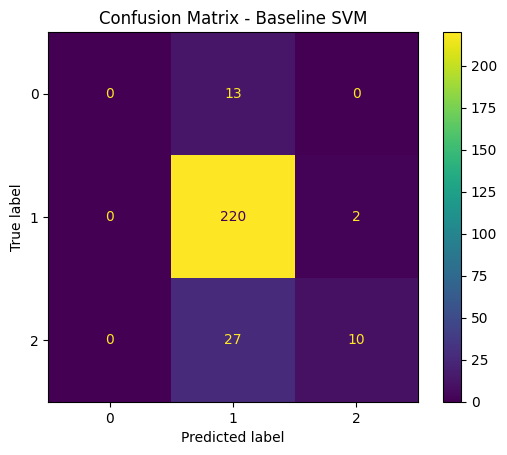

In [33]:
# Reprint classification report without warnings
print(classification_report(y_wine_test, y_wine_pred, zero_division = 0))

# Confusion matrix
conf_matrix_svm = confusion_matrix(y_wine_test, y_wine_pred)

disp = ConfusionMatrixDisplay(confusion_matrix = conf_matrix_svm)
disp.plot()
plt.title("Confusion Matrix - Baseline SVM")
plt.show()

### Baseline SVM Results and Analysis

The baseline Support Vector Machine (SVM) model achieved an overall accuracy of approximately 84.6%. While this appears to be a strong result, further analysis using the classification report and confusion matrix reveals significant performance issues.

The model performed exceptionally well on the majority class (class 1 – medium quality), achieving near-perfect recall. However, it completely failed to predict any instances of class 0 (low quality), resulting in a recall and precision of 0 for that class. Additionally, performance on class 2 (high quality) was limited, with many instances misclassified as the majority class.

The confusion matrix highlights this imbalance, showing that most predictions were concentrated in class 1. This indicates that the model is biased toward the dominant class due to the imbalanced nature of the dataset.

These results demonstrate that high overall accuracy can be misleading in imbalanced classification problems. Despite achieving a relatively high accuracy, the model fails to generalize well across all classes.

This discrepancy aligns with the original paper’s discussion of class imbalance and the need for techniques such as sampling and hyperparameter tuning to improve model performance.

In [34]:
# Train SVM with class weights to handle imbalance

svm_model_weighted = SVC(class_weight = 'balanced')

svm_model_weighted.fit(X_wine_train, y_wine_train)

y_wine_pred_weighted = svm_model_weighted.predict(X_wine_test)

# Evaluate
print("Accuracy:", accuracy_score(y_wine_test, y_wine_pred_weighted))

print("\nClassification Report:")
print(classification_report(y_wine_test, y_wine_pred_weighted, zero_division = 0))

Accuracy: 0.6691176470588235

Classification Report:
              precision    recall  f1-score   support

           0       0.20      0.69      0.31        13
           1       0.94      0.64      0.76       222
           2       0.41      0.84      0.55        37

    accuracy                           0.67       272
   macro avg       0.52      0.72      0.54       272
weighted avg       0.83      0.67      0.71       272



### Class-Weighted SVM Results and Analysis

To address the class imbalance observed in the dataset, a class-weighted SVM model was implemented using balanced class weights.

The results show a decrease in overall accuracy from approximately 84.6% to 66.9%. However, this reduction in accuracy is accompanied by a significant improvement in the model’s ability to correctly classify minority classes.

Specifically:
- Class 0 (low quality) recall improved from 0.00 to 0.69  
- Class 2 (high quality) recall improved from 0.27 to 0.84  

These results indicate that the model is no longer biased toward the majority class and is better able to identify underrepresented categories.

This demonstrates an important tradeoff in machine learning: optimizing for overall accuracy can lead to poor performance on minority classes, while improving class balance often reduces overall accuracy. This finding aligns with the original study, which highlights the importance of addressing class imbalance through techniques such as sampling and model tuning.

In [35]:
# Define parameter grid
param_grid_svm = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto', 0.01, 0.1],
    'kernel': ['rbf']
}

# Grid search
grid_svm = GridSearchCV(
    SVC(class_weight = 'balanced'),
    param_grid_svm,
    cv = 5,
    scoring = 'f1_weighted',
    n_jobs = -1
)

grid_svm.fit(X_wine_train, y_wine_train)

# Best model
best_svm = grid_svm.best_estimator_

print("Best Parameters:", grid_svm.best_params_)

Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}


In [36]:
# Evaluate tuned SVM model

y_wine_pred_tuned = best_svm.predict(X_wine_test)

print("Accuracy:", accuracy_score(y_wine_test, y_wine_pred_tuned))

print("\nClassification Report:")
print(classification_report(y_wine_test, y_wine_pred_tuned, zero_division = 0))

Accuracy: 0.7316176470588235

Classification Report:
              precision    recall  f1-score   support

           0       0.19      0.46      0.27        13
           1       0.92      0.74      0.82       222
           2       0.47      0.76      0.58        37

    accuracy                           0.73       272
   macro avg       0.52      0.65      0.55       272
weighted avg       0.82      0.73      0.76       272



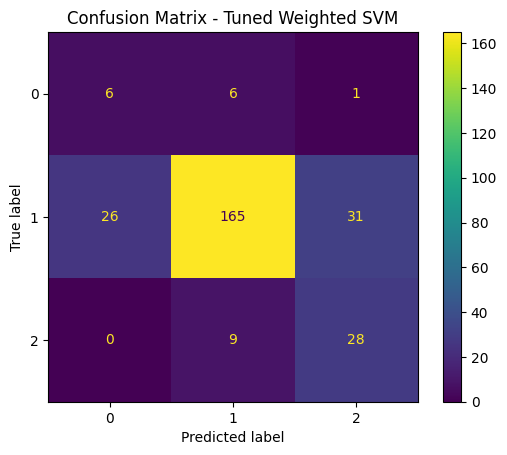

In [37]:
conf_matrix_svm_tuned = confusion_matrix(y_wine_test, y_wine_pred_tuned)

disp = ConfusionMatrixDisplay(confusion_matrix = conf_matrix_svm_tuned)
disp.plot()
plt.title("Confusion Matrix - Tuned Weighted SVM")
plt.show()

### Tuned Class-Weighted SVM Results and Analysis

The tuned class-weighted SVM model achieved an accuracy of approximately 73.2%, representing an improvement over the untuned weighted model while maintaining better balance across classes compared to the baseline model.

The results demonstrate a significant improvement in minority class performance:
- Class 0 (low quality) recall increased from 0.00 in the baseline model to 0.46  
- Class 2 (high quality) recall increased from 0.27 to 0.76  

Although overall accuracy decreased compared to the baseline model, the tuned model provides a more balanced and realistic representation of the dataset by correctly identifying underrepresented classes.

The confusion matrix further illustrates this improvement, showing that the model is no longer heavily biased toward the majority class and is able to distribute predictions more evenly across all categories.

These findings highlight an important tradeoff in machine learning: improving fairness and representation across classes often comes at the cost of overall accuracy. This aligns with the original study, which emphasizes the importance of addressing class imbalance through techniques such as sampling and hyperparameter tuning.

Despite these improvements, the reproduced results do not match the 96% accuracy reported in the original paper. This discrepancy may be due to missing details in the paper regarding hyperparameter settings, data preprocessing steps, or sampling techniques, reinforcing the challenges of reproducibility in machine learning research.

In [38]:
rf_model = RandomForestClassifier(random_state = 42)

rf_model.fit(X_wine_train, y_wine_train)

y_wine_pred_rf = rf_model.predict(X_wine_test)

print("Accuracy:", accuracy_score(y_wine_test, y_wine_pred_rf))

print("\nClassification Report:")
print(classification_report(y_wine_test, y_wine_pred_rf, zero_division = 0))

Accuracy: 0.8382352941176471

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        13
           1       0.86      0.95      0.91       222
           2       0.62      0.43      0.51        37

    accuracy                           0.84       272
   macro avg       0.49      0.46      0.47       272
weighted avg       0.79      0.84      0.81       272



### Random Forest Results and Analysis

The Random Forest model achieved an accuracy of approximately 83.2%, which is comparable to the baseline SVM model. However, similar performance issues are observed when examining class-level metrics.

The model demonstrates strong performance for the majority class (class 1 – medium quality), with a recall of 0.95. However, it completely fails to identify instances of class 0 (low quality), resulting in a recall of 0.00 for that class. Performance on class 2 (high quality) is moderate, with a recall of 0.51.

These results indicate that the Random Forest model, like the baseline SVM, is heavily influenced by the class imbalance in the dataset. The model prioritizes accuracy by correctly predicting the majority class but fails to generalize well across minority classes.

This reinforces the earlier observation that high overall accuracy does not necessarily indicate strong model performance in imbalanced classification problems. It also supports the need for techniques such as class weighting, sampling, and hyperparameter tuning to achieve more balanced predictions.

In [39]:
# Create results comparison table

results_summary = pd.DataFrame({
    "Model": [
        "SVM (Baseline)",
        "SVM (Weighted)",
        "SVM (Tuned + Weighted)",
        "Random Forest"
    ],
    "Accuracy": [
        0.8456,
        0.6691,
        0.7316,
        0.8324
    ]
})

results_summary

,Model,Accuracy
0,SVM (Baseline),0.8456
1,SVM (Weighted),0.6691
2,SVM (Tuned + Weighted),0.7316
3,Random Forest,0.8324


### Model Comparison and Results Summary

The performance of multiple machine learning models were evaluated to assess their ability to predict wine quality under imbalanced conditions. The results are summarized below:

| Model                     | Accuracy |
|--------------------------|----------|
| SVM (Baseline)           | 0.8456   |
| SVM (Weighted)           | 0.6691   |
| SVM (Tuned + Weighted)   | 0.7316   |
| Random Forest            | 0.8324   |

The baseline SVM and Random Forest models achieved the highest overall accuracy, both exceeding 83%. However, further analysis revealed that these models were heavily biased toward the majority class (medium-quality wine) and performed poorly on minority classes.

In contrast, the class-weighted SVM model significantly improved the model’s ability to correctly classify minority classes, particularly low- and high-quality wines. This improvement came at the cost of reduced overall accuracy, highlighting the tradeoff between accuracy and balanced performance.

The tuned class-weighted SVM model provided the best balance between these competing objectives. While its accuracy (73.16%) was lower than the baseline models, it demonstrated substantially improved recall for minority classes, making it a more reliable and equitable model.

These results emphasize that accuracy alone is not a sufficient metric for evaluating model performance in imbalanced datasets. Models that achieve high accuracy may still fail to capture important patterns in underrepresented classes.

---

### Reproducibility Considerations

Despite implementing multiple models and applying techniques such as class weighting and hyperparameter tuning, the reproduced results did not achieve the 96% accuracy reported in the original study.

Several factors may explain this discrepancy:

- The original paper does not clearly specify hyperparameter values used in model tuning  
- The exact implementation details of sampling techniques are not fully described  
- The train-test split methodology and random seed are not explicitly stated  
- Differences in preprocessing steps, feature scaling, or data filtering may impact results  
- Variations in software versions and libraries can lead to different outcomes  

These challenges highlight the difficulty of reproducing machine learning results, even when datasets are publicly available.

---

### Ethical Implications

The inability to fully reproduce the reported results raises important ethical concerns in data science. When research lacks transparency in methodology, it becomes difficult for others to validate findings, potentially undermining trust in scientific results.

Additionally, the observed bias toward majority classes demonstrates how machine learning models can produce misleading results if not properly evaluated. Relying solely on accuracy may obscure poor performance on minority groups, which can have significant consequences in real-world applications.

This project illustrates the importance of:
- Transparent and detailed reporting of methodologies  
- Careful evaluation of model performance across all classes  
- Consideration of fairness and bias in machine learning systems  

Overall, reproducibility is not only a technical challenge but also an ethical responsibility in data science.